Normalizing Flows is a rich family of distributions. They were discribed in [arXiv:1505.05770v6](https://arxiv.org/abs/1505.05770) and their experiments prooved the importance of studying them further. Some extensions like [arXiv:1611.09630v4](https://arxiv.org/abs/1611.09630) made computationally tractable (partially)full rank gaussians approximations for high dimansional spaces. In this notebook I'll show some tips and tricks of application normalizing flows in PyMC3

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pymc3 as pm
import numpy as np
from theano import theano, tensor as tt
pm.set_tt_rng(44)
np.random.seed(44)

There were 4 potential functions in the original paper ([arXiv:1505.05770v6](https://arxiv.org/abs/1505.05770)). It is interesting to see the behaviour of inference in this setup. In my experiments I found that inference can be very unstable in multimodality cases and there are ways to deal with it.

First of all let's recall potential functions

In [2]:
def w1(z):
    return tt.sin(2.*np.pi*z[0]/4.)
def w2(z):
    return 3.*tt.exp(-.5*(((z[0]-1.)/.6))**2)
def w3(z):
    return 3.*(1+tt.exp(-(z[0]-1.)/.3))**-1
def pot1(z):
    z = z.T
    return .5*((z.norm(2, axis=0)-2.)/.4)**2 - tt.log(tt.exp(-.5*((z[0]-2.)/.6)**2) + tt.exp(-.5*((z[0]+2.)/.6)**2))
def pot2(z):
    z = z.T
    return .5*((z[1]-w1(z))/.4)**2
def pot3(z):
    z = z.T
    return -tt.log(tt.exp(-.5*((z[1]-w1(z))/.35)**2) + tt.exp(-.5*((z[1]-w1(z)+w2(z))/.35)**2))
def pot4(z):
    z = z.T
    return -tt.log(tt.exp(-.5*((z[1]-w1(z))/.4)**2) + tt.exp(-.5*((z[1]-w1(z)+w3(z))/.35)**2))

z = tt.matrix('z')
z.tag.test_value = pm.floatX([[0., 0.]])
pot1f = theano.function([z], pot1(z))
pot2f = theano.function([z], pot2(z))
pot3f = theano.function([z], pot3(z))
pot4f = theano.function([z], pot4(z))

In [3]:
def contour_pot(potf, ax=None, title=None, xlim=5, ylim=5):
    grid = pm.floatX(np.mgrid[-xlim:xlim:100j,-ylim:ylim:100j])
    grid_2d = grid.reshape(2, -1).T
    cmap = plt.get_cmap('inferno')
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 9))
    pdf1e = np.exp(-potf(grid_2d))
    contour = ax.contourf(grid[0], grid[1], pdf1e.reshape(100, 100), cmap=cmap)
    if title is not None:
        ax.set_title(title)
    return ax

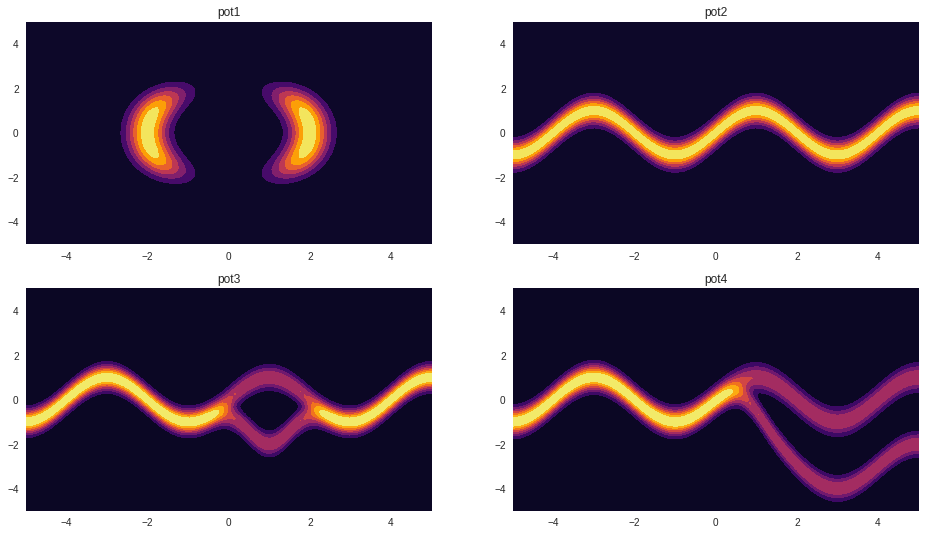

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(16, 9))
ax = ax.flatten()
contour_pot(pot1f, ax[0], 'pot1');
contour_pot(pot2f, ax[1], 'pot2');
contour_pot(pot3f, ax[2], 'pot3');
contour_pot(pot4f, ax[3], 'pot4');

## Reprodusing first potential function

In [5]:
with pm.Model() as pot1m:
    pm.DensityDist('pot1', lambda x: -pot1(x), shape=(2,))

In [6]:
with pot1m:
    trace = pm.sample(10000, init=None, start=dict(pot1=np.array([2, 0])))

Assigned NUTS to pot1
100%|██████████| 10500/10500 [00:16<00:00, 632.41it/s]


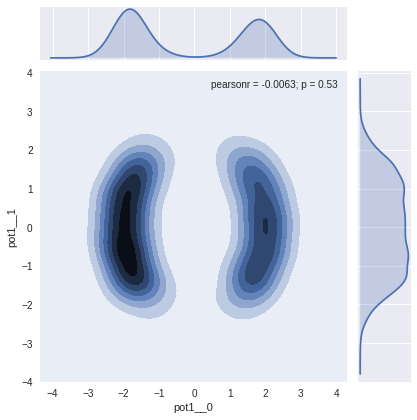

In [7]:
dftrace = pm.trace_to_dataframe(trace)
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

### First try
Let's use naive defaults and see what we'll get

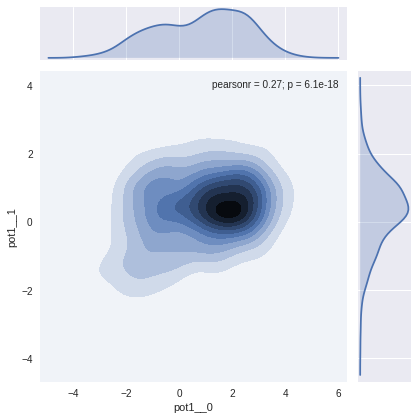

In [57]:
pm.set_tt_rng(2016)
np.random.seed(2016)
with pot1m:
    inference = pm.NF('planar*2', jitter=1)
dftrace = pm.trace_to_dataframe(inference.approx.sample(1000))
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

In [58]:
inference.fit(25000)

Average Loss = 0.27372: 100%|██████████| 25000/25000 [00:07<00:00, 3204.22it/s]    
Finished [100%]: Average Loss = 0.25368


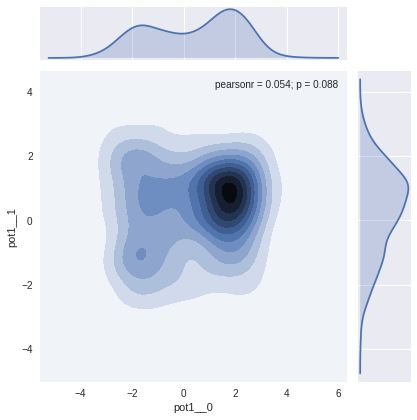

In [59]:
dftrace = pm.trace_to_dataframe(inference.approx.sample(1000))
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

We can see poor multimodality (due to carefully chosen random seed and init). But it is not similar to what we've seen above. That can be due to 2 reasons:

* Convergence is unstable and collapses to a mode
* We still did not converge
* random seed? nah

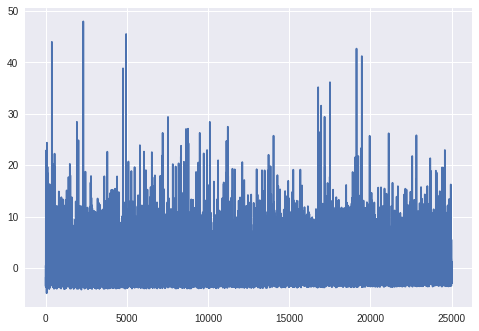

In [60]:
plt.plot(inference.hist)

This loss history is not very informative. We do not see significant improvements during inference. Let's try to continue infernece since it is rather fast.

In [61]:
inference.fit(50000)

Average Loss = -0.65558: 100%|██████████| 50000/50000 [00:15<00:00, 3174.63it/s] 
Finished [100%]: Average Loss = -0.66386


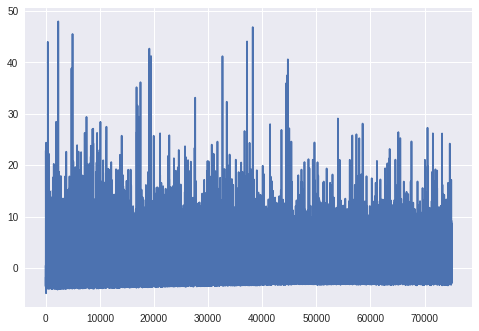

In [62]:
plt.plot(inference.hist);

We agein see no clear picture. What about sampling?

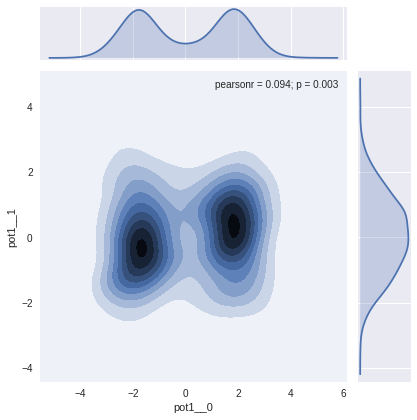

In [63]:
dftrace = pm.trace_to_dataframe(inference.approx.sample(1000))
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

Picture is much better. You can try to rerun the experiments setting
```python
pm.set_tt_rng(2017)
np.random.seed(2017)
with pot1m:
    inference = pm.NF('planar*2', jitter=1)
```
You'll be surprised how random seed matters when objective has multimodal distribution. 

Let's see what is happening with gradients during inference

In [65]:
pm.set_tt_rng(2017)
np.random.seed(2017)
with pot1m:
    inference = pm.NF('planar*2', jitter=1)

In [66]:
# here are params
inference.approx.params

[_u, _w, b, _u, _w, b]

In [67]:
# here is objective
inference.objective(nmc=None)

Elemwise{mul,no_inplace}.0

In [68]:
# here are gradients
tt.grad(inference.objective(None), inference.approx.params)

[Elemwise{add,no_inplace}.0,
 Elemwise{add,no_inplace}.0,
 Elemwise{add,no_inplace}.0,
 Elemwise{add,no_inplace}.0,
 Elemwise{add,no_inplace}.0,
 Elemwise{add,no_inplace}.0]

In [69]:
# all in
def get_tracker(inference):
    grads = tt.grad(inference.objective(None), inference.approx.params)
    return pm.callbacks.Tracker(**dict([(str(i), g.eval) for i, g in enumerate(grads)]))
tracker = get_tracker(inference)

In [70]:
inference.fit(25000, obj_optimizer=pm.adam, callbacks=[tracker])

Average Loss = -1.0674: 100%|██████████| 25000/25000 [00:37<00:00, 666.24it/s]  
Finished [100%]: Average Loss = -1.0663


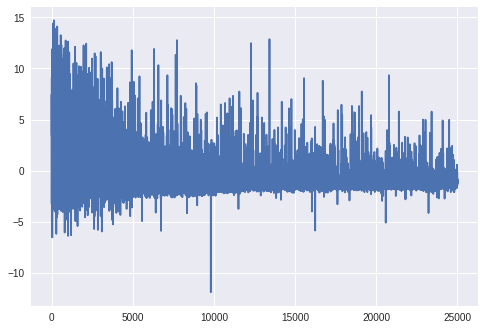

In [71]:
plt.plot(inference.hist);

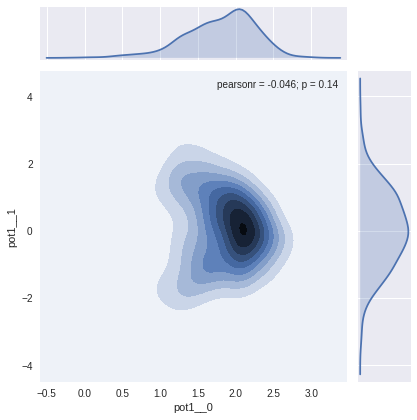

In [72]:
dftrace = pm.trace_to_dataframe(inference.approx.sample(1000))
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

We really depend on random seed of initializatoin so be careful

In [73]:
tracker.hist.keys()

dict_keys(['0', '1', '2', '3', '4', '5'])

In [74]:
def plot_tracker_results(tracker):
    fig, ax = plt.subplots(3, 2, figsize=(16, 12))
    ax = ax.flatten()
    ax[0].plot(np.asarray(tracker.hist['0'])[:, 0], 'o', alpha=.2)
    ax[0].plot(np.asarray(tracker.hist['0'])[:, 1], 'o', alpha=.2)

    ax[1].plot(np.asarray(tracker.hist['1'])[:, 0], 'o', alpha=.2)
    ax[1].plot(np.asarray(tracker.hist['1'])[:, 1], 'o', alpha=.2)

    ax[2].plot(np.asarray(tracker.hist['2']), 'o', alpha=.2)

    ax[3].plot(np.asarray(tracker.hist['3'])[:, 0], 'o', alpha=.2)
    ax[3].plot(np.asarray(tracker.hist['3'])[:, 1], 'o', alpha=.2)

    ax[4].plot(np.asarray(tracker.hist['4'])[:, 0], 'o', alpha=.2)
    ax[4].plot(np.asarray(tracker.hist['4'])[:, 1], 'o', alpha=.2)

    ax[5].plot(np.asarray(tracker.hist['5']), 'o', alpha=.2)

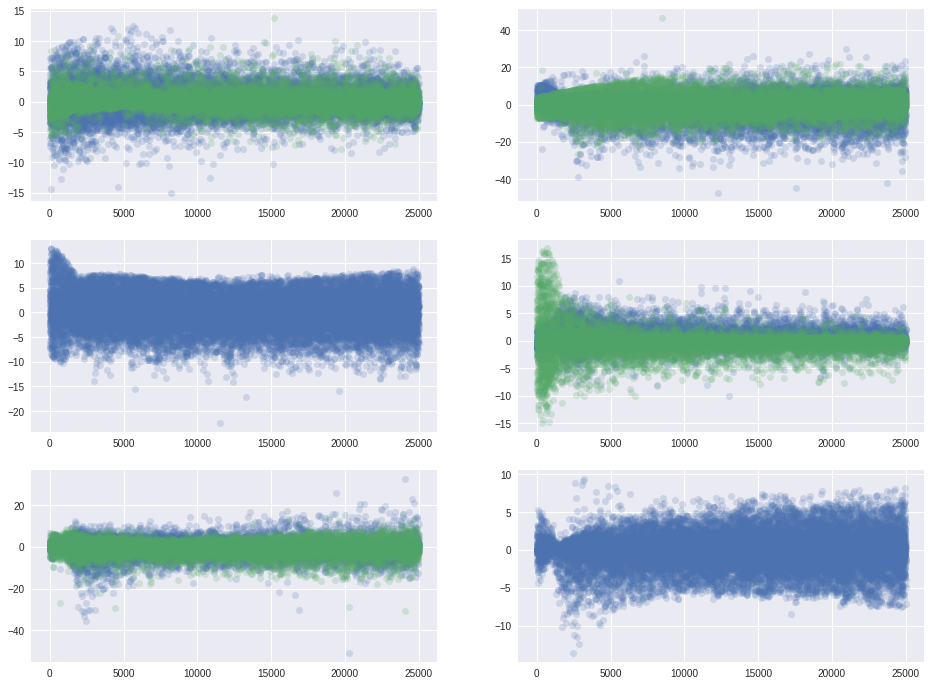

In [75]:
plot_tracker_results(tracker)

Variance differs from time to time. Even when a lot of training steps are done some parameters still have high variance gradients. This of course bad for our optimizer since preconditioning done by ADAM scales down gradients and trainig becomes really hard. No chance to jump away from local optimum

Let's try again with sgd

### Going deeper
We can try to improve our approximation using more flows, in paper they used 8 and 32, let's start with 8 too.

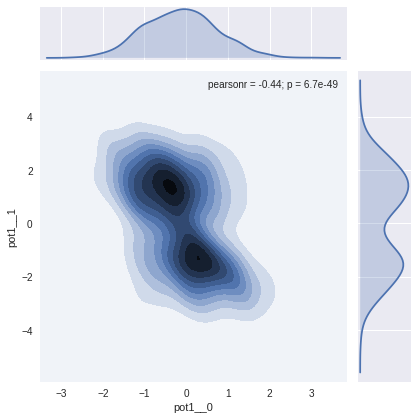

In [24]:
pm.set_tt_rng(2017)
np.random.seed(2017)
with pot1m:
    inference = pm.NF('planar*8', jitter=.5)
dftrace = pm.trace_to_dataframe(inference.approx.sample(1000))
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

To reduce gradients noise we can use moe `obj_n_mc` in `fit`

In [25]:
inference.fit(25000, obj_optimizer=pm.adam(learning_rate=0.005), obj_n_mc=30)

Average Loss = -1.7488: 100%|██████████| 25000/25000 [00:54<00:00, 458.97it/s]
Finished [100%]: Average Loss = -1.7492


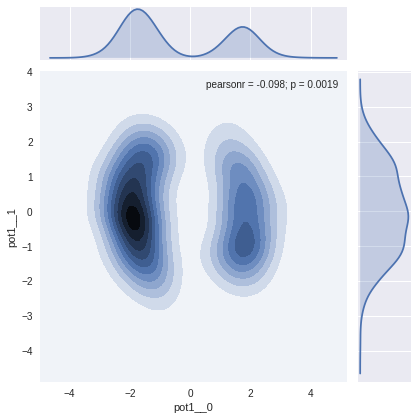

In [26]:
dftrace = pm.trace_to_dataframe(inference.approx.sample(1000))
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

Nice one

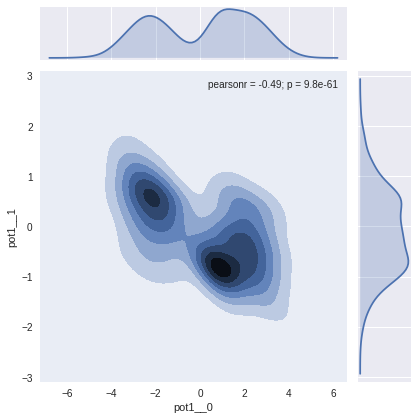

In [7]:
pm.set_tt_rng(2017)
np.random.seed(2017)
with pot1m:
    inference = pm.NF('planar*20', jitter=.5)
dftrace = pm.trace_to_dataframe(inference.approx.sample(1000))
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

In [8]:
inference.fit(45000, obj_optimizer=pm.adam, obj_n_mc=30)

Average Loss = -1.5497: 100%|██████████| 45000/45000 [03:36<00:00, 208.06it/s]
Finished [100%]: Average Loss = -1.5503


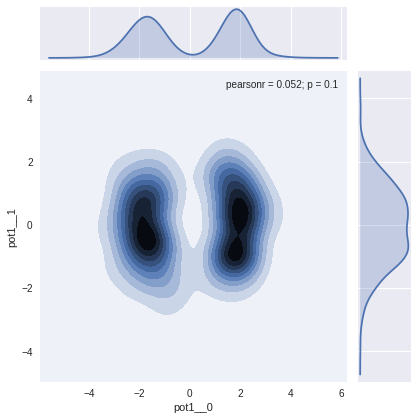

In [9]:
dftrace = pm.trace_to_dataframe(inference.approx.sample(1000))
sns.jointplot(dftrace.iloc[:, 0], dftrace.iloc[:, 1], kind='kde')

Now we see that flows are able to catch multimodality structure of given posterior but in this case they are hard to fit due to gradient variance and bad initial points.